## EDA - FastF1

## 1. Chargement des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\imane\Desktop\Fil-rouge")

df_fastf1 = pd.read_csv(PROJECT_DIR / "data/raw/fastf1_kpis_R_Q_2021_2025.csv")
df_driver_fin = pd.read_csv(PROJECT_DIR / "data/raw/f1_driver_finance_2021_2025.csv")
df_constructor_fin = pd.read_csv(PROJECT_DIR / "data/raw/f1_constructor_finance_2021_2025.csv")

## 2. Analyse Structurelle

### 2.1 Dimensions générales

In [2]:
df_fastf1.shape
df_fastf1.info()
df_fastf1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5056 entries, 0 to 5055
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           5056 non-null   int64  
 1   round            5056 non-null   int64  
 2   gp               5056 non-null   object 
 3   session          5056 non-null   object 
 4   circuit          5056 non-null   object 
 5   driverCode       5056 non-null   object 
 6   bestLapTime_sec  5056 non-null   float64
 7   avgLapTime_sec   5056 non-null   float64
 8   stdLapTime_sec   4975 non-null   float64
 9   maxSpeed_kmh     5039 non-null   float64
 10  gridPosition     2510 non-null   float64
 11  finishPosition   5056 non-null   float64
 12  qualyPosition    2546 non-null   float64
dtypes: float64(7), int64(2), object(4)
memory usage: 513.6+ KB


,season,round,bestLapTime_sec,avgLapTime_sec,stdLapTime_sec,maxSpeed_kmh,gridPosition,finishPosition,qualyPosition
count,5056.000000,5056.000000,5056.000000,5056.000000,4975.000000,5039.000000,2510.000000,5056.000000,2546.000000
mean,2022.957081,12.200356,87.402395,88.559374,0.795682,316.799984,10.247410,10.173259,10.265907
std,1.418521,6.319048,12.184150,12.381173,0.411294,19.382079,5.811554,5.630710,5.676788
min,2021.000000,1.000000,63.720000,63.974000,0.001414,0.000000,0.000000,1.000000,1.000000
25%,2022.000000,7.000000,78.378000,79.408324,0.481572,306.000000,5.000000,5.000000,5.000000
50%,2023.000000,12.000000,87.979000,89.034575,0.758428,319.000000,10.000000,10.000000,10.000000
75%,2024.000000,17.000000,94.945500,95.994000,1.037772,328.000000,15.000000,15.000000,15.000000
max,2025.000000,24.000000,219.679000,219.679000,3.407662,356.000000,20.000000,20.000000,20.000000


### 2.2 Valeurs manquantes

In [3]:
df_fastf1.isnull().sum().sort_values(ascending=False)

gridPosition       2546
qualyPosition      2510
stdLapTime_sec       81
maxSpeed_kmh         17
season                0
circuit               0
session               0
gp                    0
round                 0
avgLapTime_sec        0
bestLapTime_sec       0
driverCode            0
finishPosition        0
dtype: int64

## 3. Complétude des saisons

In [4]:
df_fastf1.groupby(["season","session"])["round"].nunique()

season  session
2021    Q          22
        R          22
2022    Q          22
        R          22
2023    Q          22
        R          22
2024    Q          24
        R          24
2025    Q          24
        R          24
Name: round, dtype: int64

## 4. Analyse Performance Pilote

### 4.1 Distribution des best lap times

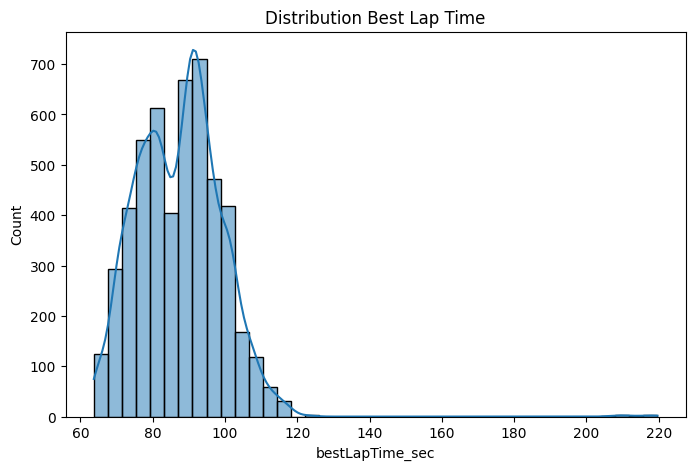

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df_fastf1["bestLapTime_sec"], bins=40, kde=True)
plt.title("Distribution Best Lap Time")
plt.show()

### 4.2 Consistency Index (std lap)

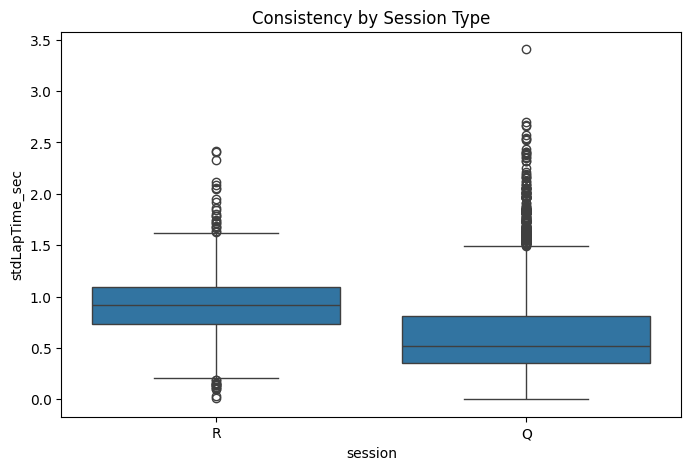

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x="session", y="stdLapTime_sec", data=df_fastf1)
plt.title("Consistency by Session Type")
plt.show()

## 5. Vitesse max

In [8]:
df_fastf1["maxSpeed_kmh"].describe()

count    5039.000000
mean      316.799984
std        19.382079
min         0.000000
25%       306.000000
50%       319.000000
75%       328.000000
max       356.000000
Name: maxSpeed_kmh, dtype: float64

## 6. Race Gain

In [9]:
df_fastf1["raceGain"] = df_fastf1["gridPosition"] - df_fastf1["finishPosition"]
df_fastf1["raceGain"].describe()

count    2510.000000
mean        0.168127
std         4.796083
min       -19.000000
25%        -2.000000
50%         0.000000
75%         2.000000
max        18.000000
Name: raceGain, dtype: float64

## 8. Détection des Outliers

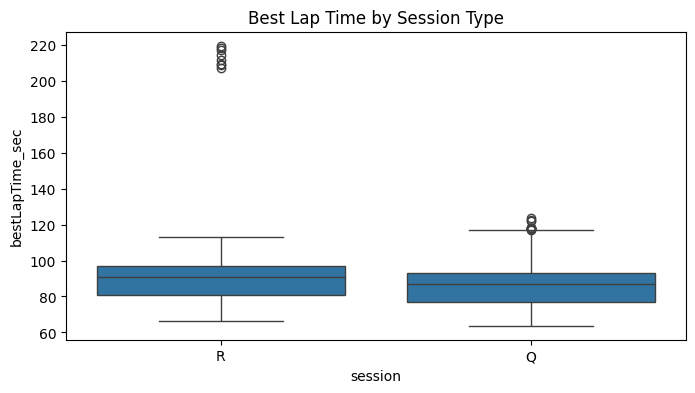

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x="session", y="bestLapTime_sec", data=df_fastf1)
plt.title("Best Lap Time by Session Type")
plt.show()

## 9. Cohérence session ↔ positions

In [11]:
df_fastf1.groupby("session")[["gridPosition","qualyPosition"]].apply(lambda x: x.isna().mean())

,gridPosition,qualyPosition
session,,
Q,1.0,0.0
R,0.0,1.0


## 10. Vérification Pre-Season Test

In [12]:
df_fastf1["gp"].value_counts().head(10)

gp
Pre-Season Testing          320
Pre-Season Test             240
Pre-Season Track Session    222
Bahrain Grand Prix          198
Abu Dhabi Grand Prix        198
United States Grand Prix    197
Spanish Grand Prix          197
Italian Grand Prix          197
Austrian Grand Prix         196
Azerbaijan Grand Prix       196
Name: count, dtype: int64

## 11. Analyse corrélation interne

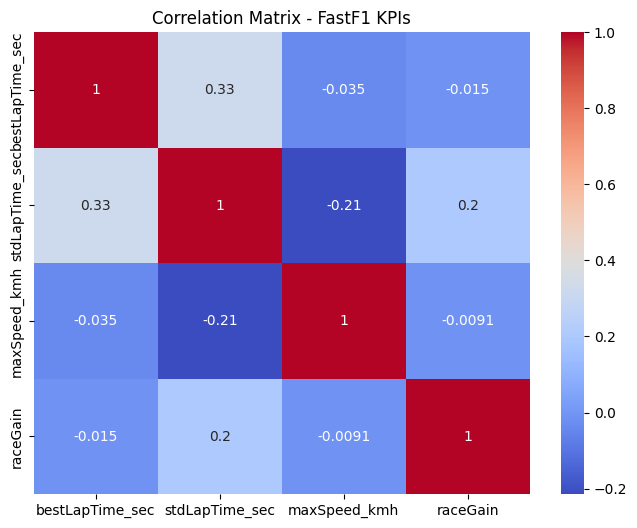

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df_fastf1[[
        "bestLapTime_sec",
        "stdLapTime_sec",
        "maxSpeed_kmh",
        "raceGain"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix - FastF1 KPIs")
plt.show()

## 12. Analyse par saison

<Axes: xlabel='season', ylabel='bestLapTime_sec'>

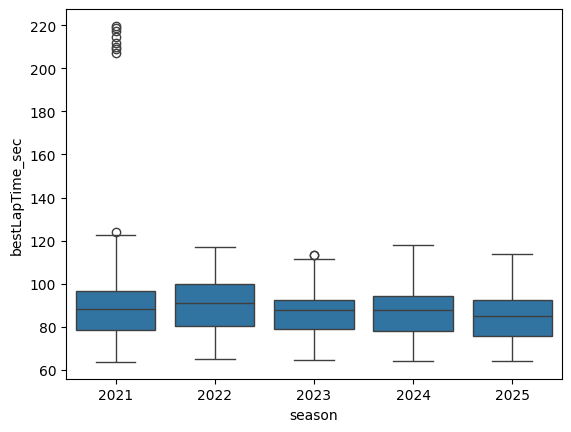

In [14]:
df_fastf1.groupby("season")["bestLapTime_sec"].mean()
sns.boxplot(x="season", y="bestLapTime_sec", data=df_fastf1)

## EDA - F1 constructor finance

## 1. Structure & Intégrité des données

### 1.1 Dimensions


In [15]:
df_constructor_fin.shape
df_constructor_fin.describe()

,season,constructorRank,constructorPoints,costCapUSD
count,50.000000,50.000000,50.000000,5.000000e+01
mean,2023.000000,5.500000,246.290000,1.380000e+08
std,1.428571,2.901442,254.065014,4.040610e+06
min,2021.000000,1.000000,0.000000,1.350000e+08
25%,2022.000000,3.000000,39.250000,1.350000e+08
50%,2023.000000,5.500000,128.500000,1.350000e+08
75%,2024.000000,8.000000,440.500000,1.400000e+08
max,2025.000000,10.000000,860.000000,1.450000e+08


### 1.2 Types & colonnes

In [4]:
df_constructor_fin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   season             50 non-null     int64  
 1   constructorId      50 non-null     object 
 2   constructorName    50 non-null     object 
 3   constructorRank    50 non-null     int64  
 4   constructorPoints  50 non-null     float64
 5   costCapUSD         50 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 2.5+ KB


### 1.3 Valeurs manquantes

In [5]:
df_constructor_fin.isnull().sum()

season               0
constructorId        0
constructorName      0
constructorRank      0
constructorPoints    0
costCapUSD           0
dtype: int64

## 2. Vérification Cohérence Métier

### 2.1 Nombre d’équipes par saison

In [6]:
df_constructor_fin.groupby("season")["constructorId"].nunique()

season
2021    10
2022    10
2023    10
2024    10
2025    10
Name: constructorId, dtype: int64

### 2.2 Vérification Budget Cap par saison

In [7]:
df_constructor_fin.groupby("season")["costCapUSD"].mean()

season
2021    145000000.0
2022    140000000.0
2023    135000000.0
2024    135000000.0
2025    135000000.0
Name: costCapUSD, dtype: float64

## Analyse des Performances (Points)

### 3.1 Distribution globale des points

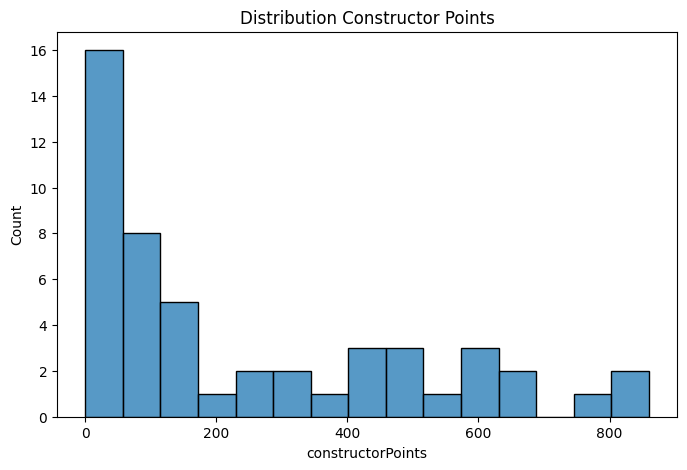

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df_constructor_fin["constructorPoints"], bins=15)
plt.title("Distribution Constructor Points")
plt.show()

### 3.2 Points par saison

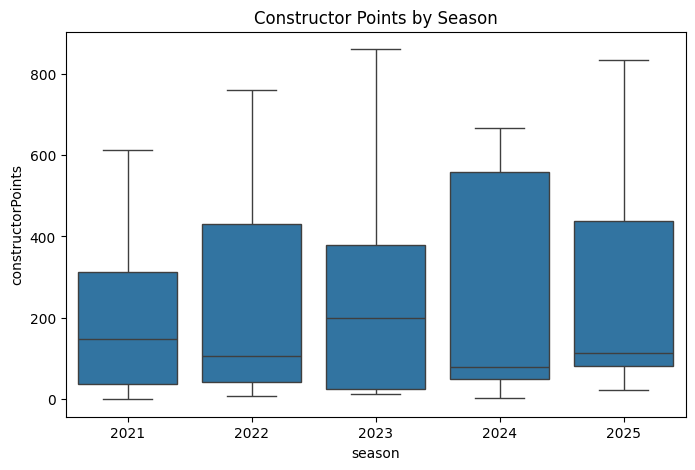

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x="season", y="constructorPoints", data=df_constructor_fin)
plt.title("Constructor Points by Season")
plt.show()

## Validation Logique Rang ↔ Points

### 4.1 Corrélation Rang / Points

In [10]:
df_constructor_fin[["constructorRank","constructorPoints"]].corr()

,constructorRank,constructorPoints
constructorRank,1.000000,-0.905986
constructorPoints,-0.905986,1.000000


### 4.2 Visualisation

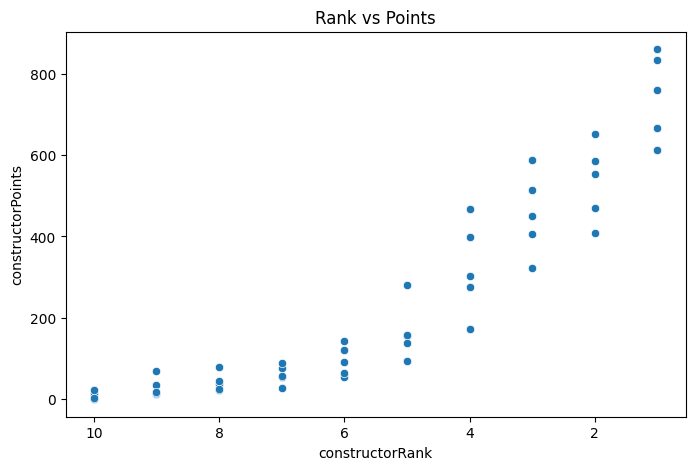

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_constructor_fin,
    x="constructorRank",
    y="constructorPoints"
)
plt.gca().invert_xaxis()
plt.title("Rank vs Points")
plt.show()

## 5. Analyse Corrélation Globale

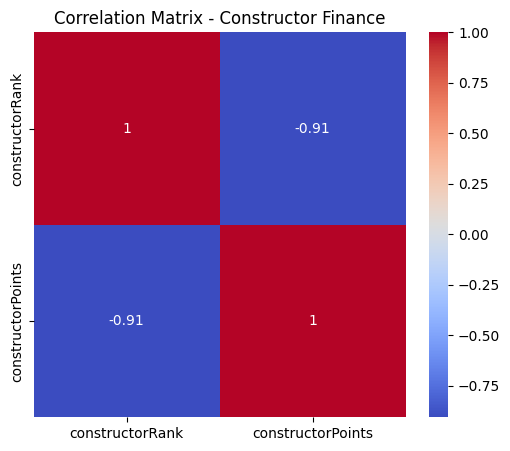

In [14]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df_constructor_fin[[
        "constructorRank",
        "constructorPoints"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix - Constructor Finance")
plt.show()

## EDA - F1 driver finance

### 1. Structure & Intégrité

In [16]:
df_driver_fin.shape
df_driver_fin.describe()

,season,driverRank,driverPoints,estimatedSalaryUSD
count,110.000000,110.000000,110.000000,1.0
mean,2023.018182,11.527273,111.950000,1000000.0
std,1.401060,6.422022,134.594378,NaN
min,2021.000000,1.000000,0.000000,1000000.0
25%,2022.000000,6.000000,10.500000,1000000.0
50%,2023.000000,11.500000,42.500000,1000000.0
75%,2024.000000,17.000000,197.500000,1000000.0
max,2025.000000,24.000000,575.000000,1000000.0


## 2. Types & Colonnes

In [17]:
df_driver_fin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   season              110 non-null    int64  
 1   driverId            110 non-null    object 
 2   driverName          110 non-null    object 
 3   constructorId       110 non-null    object 
 4   driverRank          110 non-null    int64  
 5   driverPoints        110 non-null    float64
 6   salary_raw          18 non-null     object 
 7   estimatedSalaryUSD  1 non-null      float64
 8   salarySourceURL     18 non-null     object 
dtypes: float64(2), int64(2), object(5)
memory usage: 7.9+ KB


## 3. Valeurs Manquantes

In [18]:
df_driver_fin.isnull().sum()

season                  0
driverId                0
driverName              0
constructorId           0
driverRank              0
driverPoints            0
salary_raw             92
estimatedSalaryUSD    109
salarySourceURL        92
dtype: int64

## 4. Cohérence Métier

### 4.1 Nombre de pilotes par saison

In [19]:
df_driver_fin.groupby("season")["driverId"].nunique()

season
2021    21
2022    22
2023    22
2024    24
2025    21
Name: driverId, dtype: int64

### 4.2 Distribution des salaires

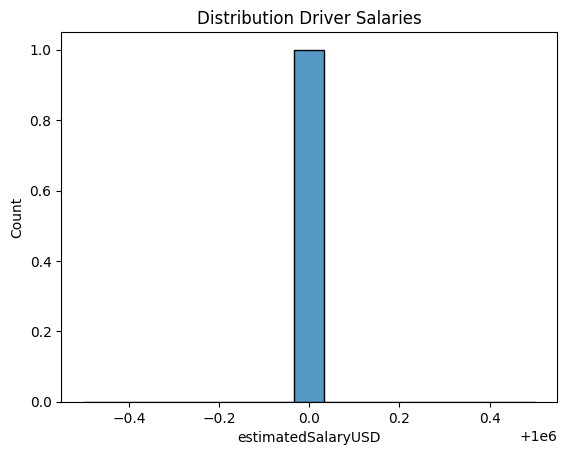

In [20]:
sns.histplot(df_driver_fin["estimatedSalaryUSD"], bins=15)
plt.title("Distribution Driver Salaries")
plt.show()

### 4.3 Top salaires

In [21]:
df_driver_fin.sort_values("estimatedSalaryUSD", ascending=False).head(10)

,season,driverId,driverName,constructorId,driverRank,driverPoints,salary_raw,estimatedSalaryUSD,salarySourceURL
99,2025,hulkenberg,Nico Hülkenberg,sauber,11,51.0,Stake F1/Audi,1000000.0,https://racingnews365.com/2025-f1-driver-salar...
0,2021,max_verstappen,Max Verstappen,red_bull,1,395.5,NaN,NaN,NaN
1,2021,hamilton,Lewis Hamilton,mercedes,2,387.5,NaN,NaN,NaN
2,2021,bottas,Valtteri Bottas,mercedes,3,226.0,NaN,NaN,NaN
3,2021,perez,Sergio Pérez,red_bull,4,190.0,NaN,NaN,NaN
4,2021,sainz,Carlos Sainz,ferrari,5,164.5,NaN,NaN,NaN
5,2021,norris,Lando Norris,mclaren,6,160.0,NaN,NaN,NaN
6,2021,leclerc,Charles Leclerc,ferrari,7,159.0,NaN,NaN,NaN
7,2021,ricciardo,Daniel Ricciardo,mclaren,8,115.0,NaN,NaN,NaN
8,2021,gasly,Pierre Gasly,alphatauri,9,110.0,NaN,NaN,NaN


## 5. Analyse Performance ↔ Salaire

### Corrélation Salary ↔ Points

In [22]:
df_driver_fin[["estimatedSalaryUSD","driverPoints"]].corr()

,estimatedSalaryUSD,driverPoints
estimatedSalaryUSD,NaN,NaN
driverPoints,NaN,1.0


## Visualisation

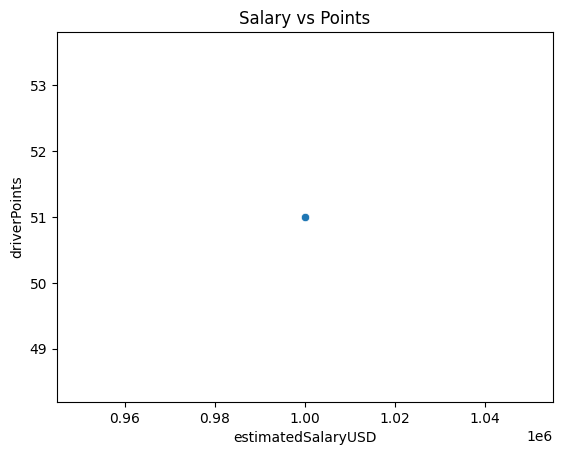

In [23]:
sns.scatterplot(
    x="estimatedSalaryUSD",
    y="driverPoints",
    data=df_driver_fin
)
plt.title("Salary vs Points")
plt.show()